# Lab 4 — Zadanie 3
## Analiza jakości wody: dane lotnicze (hiperspektralne) vs Sentinel-2
### Rzeka Odra — sceny 008 / 013 / 015, misja `221000`

Notebook realizuje:
1. Kompozyty fałszywych barw z kostki hiperspektralnej
2. Wskaźniki jakości wody: Chl-a (NDCI), DOC proxy, turbidity
3. Pobieranie danych Sentinel-2 bliskich dacie akwizycji lotniczej
4. Obliczenie tych samych wskaźników dla S2 i porównanie wyników

## 0. Instalacja zależności

In [ ]:
# Uruchom raz, jesli brakuje bibliotek
# !pip install spectral matplotlib numpy scipy requests rasterio

In [22]:
conda install libgdal-jp2openjpeg

Jupyter detected...
3 channel Terms of Service accepted
Channels:
 - defaults
Platform: win-64
Solving environment: done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.




==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.3.1

Please update conda by running

    $ conda update -n base -c defaults conda




## 1. Konfiguracja

In [1]:
from pathlib import Path

SCENE = "008"

DATA_DIR = Path(r"C:\Users\mzawa\eolabs\lab_5\data\images")
HDR_PATH = DATA_DIR / f"221000_Odra_HS_Blok_A_{SCENE}_VS_join_atm.hdr"

# Data akwizycji
ACQUISITION_DATE = "20221005"

# Copernicus Data Space (https://dataspace.copernicus.eu/)
CDSE_USER     = "e-mail"  # <-- zmien
CDSE_PASSWORD = "password"     # <-- zmien

S2_DIR = Path(r"C:\Users\mzawa\eolabs\lab_5\data\sentinel2")
S2_DIR.mkdir(parents=True, exist_ok=True)

print(f"Scena: {HDR_PATH.name}")
print(f"Plik HDR istnieje: {HDR_PATH.exists()}")

Scena: 221000_Odra_HS_Blok_A_008_VS_join_atm.hdr
Plik HDR istnieje: True


## 2. Wczytanie danych hiperspektralnych

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import spectral.io.envi as envi

img  = envi.open(str(HDR_PATH))
meta = img.metadata

# Rozmiary scen:
#   008: 2001 x 4300 px  (17.4 GB)
#   013: 4324 x 1800 px  (18.0 GB)
#   015: 3862 x 2838 px  (10.0 GB)
print(f"Rozmiar: {img.nrows} wierszy x {img.ncols} kolumn x {img.nbands} pasm")

# Zakresy dlugosc fal: 414.13 - 2498.89 nm (456 pasm, krok ~3.2-5.4 nm)
wavelengths = np.array([float(w) for w in meta["wavelength"]])
print(f"Zakres: {wavelengths[0]:.1f} - {wavelengths[-1]:.1f} nm  ({img.nbands} pasm)")

# Stale z naglowka
IGNORE_VAL = 15000.0    # data ignore value
REFL_SCALE = 10000.0    # reflectance scale factor

# default_bands (1-based): 75, 46, 19  =>  0-based: 74, 45, 18
R_IDX, G_IDX, B_IDX = 74, 45, 18
print(f"RGB (0-based): R={R_IDX} ({wavelengths[R_IDX]:.1f} nm), "
      f"G={G_IDX} ({wavelengths[G_IDX]:.1f} nm), "
      f"B={B_IDX} ({wavelengths[B_IDX]:.1f} nm)")

def find_band(target_nm):
    """Indeks pasma najblizszego zadanej dlugosci fali [nm]."""
    return int(np.argmin(np.abs(wavelengths - target_nm)))

# Pasma do wskaznikow jakosci wody (wyznaczone z listy dlugosc fal)
BAND = {
    490: find_band(490),   # pasmo 24  (490.85 nm)
    550: find_band(550),   # pasmo 43  (551.58 nm)
    665: find_band(665),   # pasmo 78  (663.46 nm)
    670: find_band(670),   # pasmo 80  (669.85 nm)
    700: find_band(700),   # pasmo 89  (698.62 nm)
    860: find_band(860),   # pasmo 139 (858.46 nm)
}
print("\nPasma uzywane do wskaznikow:")
for nm, idx in BAND.items():
    print(f"  {nm} nm => pasmo {idx:3d} ({wavelengths[idx]:.2f} nm)")

Rozmiar: 4300 wierszy x 2001 kolumn x 456 pasm
Zakres: 414.1 - 2498.9 nm  (456 pasm)
RGB (0-based): R=74 (650.7 nm), G=45 (558.0 nm), B=18 (471.7 nm)

Pasma uzywane do wskaznikow:
  490 nm => pasmo  24 (490.85 nm)
  550 nm => pasmo  43 (551.58 nm)
  665 nm => pasmo  78 (663.46 nm)
  670 nm => pasmo  80 (669.85 nm)
  700 nm => pasmo  89 (698.62 nm)
  860 nm => pasmo 139 (858.46 nm)


## 3. Kompozyty falszywych barw

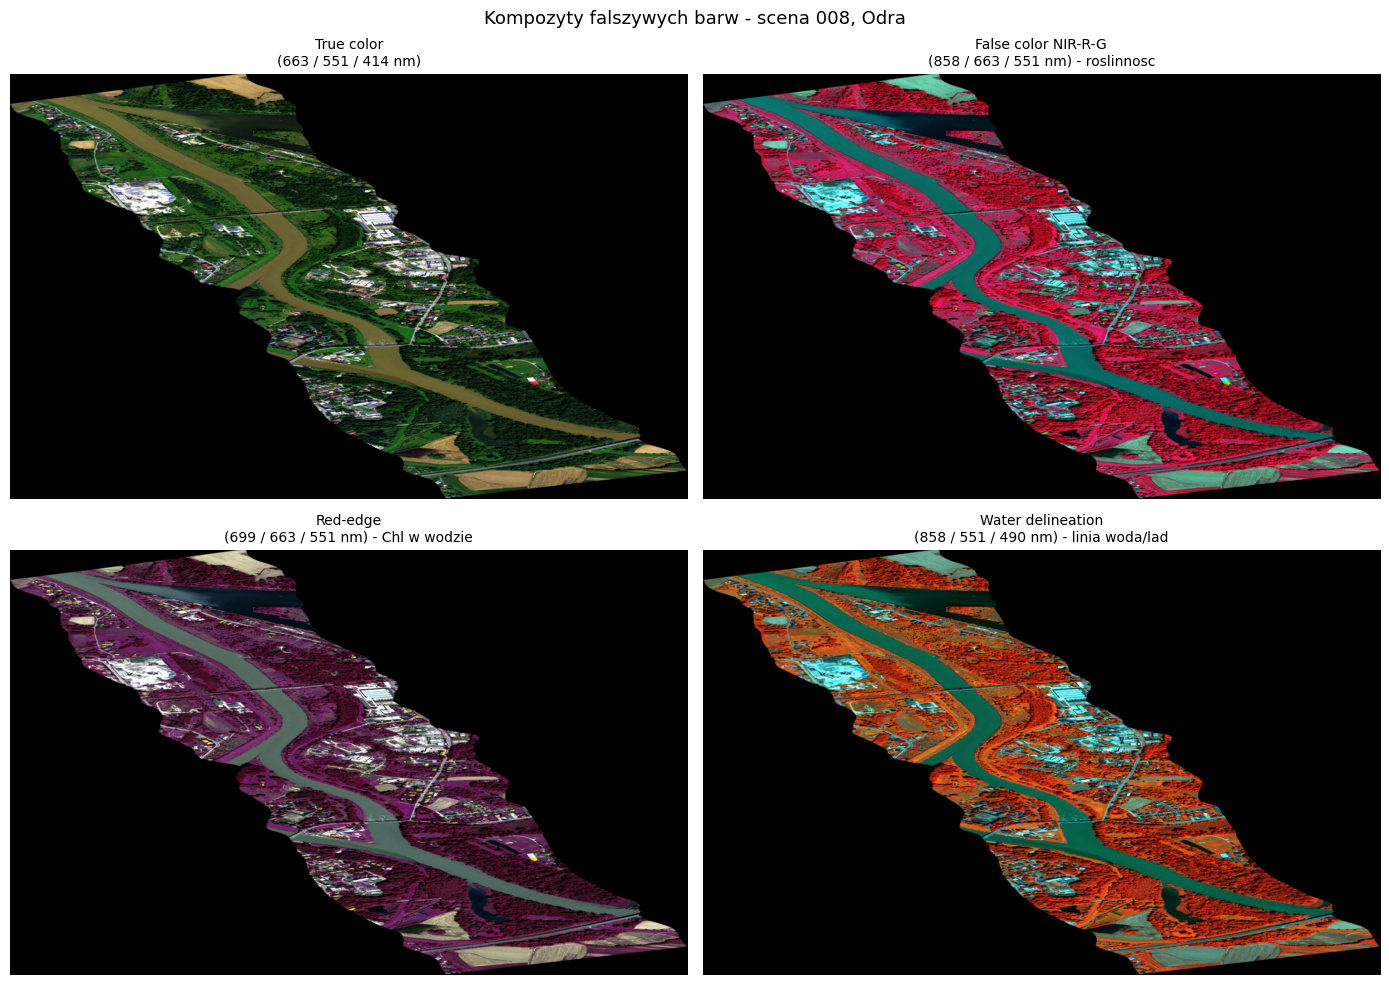

Zapisano: composites_008.png


In [3]:
def read_band(idx):
    b = img.read_bands([idx])[:, :, 0].astype(np.float64)
    b[b >= IGNORE_VAL] = np.nan
    b[b < 0]           = np.nan
    return b

def stretch(arr, p_low=2, p_high=98):
    a = arr.copy().astype(np.float32)
    p2, p98 = np.nanpercentile(a, [p_low, p_high])
    return np.clip((a - p2) / max(p98 - p2, 1e-6), 0, 1)

def make_composite(r, g, b):
    raw = img.read_bands([r, g, b]).astype(np.float32)
    raw[raw >= IGNORE_VAL] = np.nan
    raw[raw < 0]           = np.nan
    out = np.zeros_like(raw)
    for c in range(3):
        out[:, :, c] = stretch(raw[:, :, c])
    return np.nan_to_num(out)

# Cztery kompozyty dobrane do obserwacji rzeki Odra
composites = {
    "True color\n(663 / 551 / 414 nm)": (
        find_band(663), find_band(551), find_band(414)),
    "False color NIR-R-G\n(858 / 663 / 551 nm) - roslinnosc": (
        find_band(858), find_band(663), find_band(551)),
    "Red-edge\n(699 / 663 / 551 nm) - Chl w wodzie": (
        find_band(699), find_band(663), find_band(551)),
    "Water delineation\n(858 / 551 / 490 nm) - linia woda/lad": (
        find_band(858), find_band(551), find_band(490)),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (title, (r, g, b)) in zip(axes.flat, composites.items()):
    ax.imshow(make_composite(r, g, b), interpolation="bilinear", aspect="auto")
    ax.set_title(title, fontsize=10)
    ax.axis("off")

fig.suptitle(f"Kompozyty falszywych barw - scena {SCENE}, Odra", fontsize=13)
fig.tight_layout()
plt.savefig(f"composites_{SCENE}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Zapisano: composites_{SCENE}.png")

## 4. Wskazniki jakosci wody - dane lotnicze

| Wskaznik | Formula | Pasma (0-based) |
|---|---|---|
| **NDCI** (Chl-a) | `(R700 - R670) / (R700 + R670)` | 89 i 80 |
| **DOC proxy** | `R490 / R665` | 24 i 78 |
| **Turbidity** | `R860 / R550` | 139 i 43 |

> Wartosci w pliku = reflektancja x 10000. Wskazniki sa bezwymiarowe (ilorazy), wiec skalowanie nie ma znaczenia.

Wczytywanie pasm...
OK


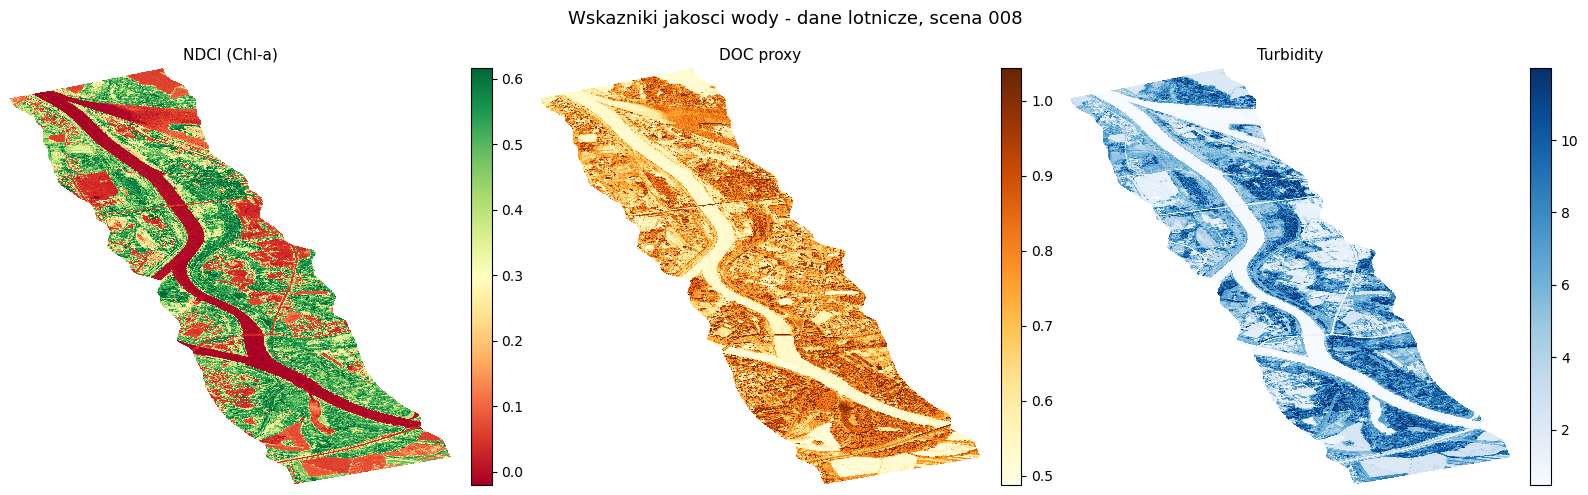


Wskaznik                 Mean      Std       P5      P95
--------------------------------------------------------
NDCI (Chl-a)           0.3148   0.2208  -0.0111   0.5929
DOC proxy              0.7222   0.1562   0.5079   0.9773
Turbidity              5.0948   3.4021   0.5264  10.8379


In [4]:
def safe_ratio(a, b):
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.where(b != 0, a / b, np.nan)

print("Wczytywanie pasm...")
R490 = read_band(BAND[490])
R550 = read_band(BAND[550])
R665 = read_band(BAND[665])
R670 = read_band(BAND[670])
R700 = read_band(BAND[700])
R860 = read_band(BAND[860])
print("OK")

NDCI_air = safe_ratio(R700 - R670, R700 + R670)
DOC_air  = safe_ratio(R490, R665)
TURB_air = safe_ratio(R860, R550)

indices_air = {"NDCI (Chl-a)": NDCI_air, "DOC proxy": DOC_air, "Turbidity": TURB_air}
CMAPS       = {"NDCI (Chl-a)": "RdYlGn", "DOC proxy": "YlOrBr", "Turbidity": "Blues"}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, data) in zip(axes, indices_air.items()):
    valid = data[~np.isnan(data)]
    vmin, vmax = np.percentile(valid, [2, 98])
    im = ax.imshow(data, cmap=CMAPS[name], vmin=vmin, vmax=vmax,
                   interpolation="nearest", aspect="auto")
    ax.set_title(name, fontsize=11)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(f"Wskazniki jakosci wody - dane lotnicze, scena {SCENE}", fontsize=13)
fig.tight_layout()
plt.savefig(f"water_quality_airborne_{SCENE}.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n{'Wskaznik':<20} {'Mean':>8} {'Std':>8} {'P5':>8} {'P95':>8}")
print("-" * 56)
for name, data in indices_air.items():
    v = data[~np.isnan(data)]
    print(f"{name:<20} {np.mean(v):>8.4f} {np.std(v):>8.4f} "
          f"{np.percentile(v,5):>8.4f} {np.percentile(v,95):>8.4f}")

## 5. Pobieranie danych Sentinel-2

Sceny lotnicze pokrywaja Odre w okolicach Raciborza / Wodzislawia Slaskiego:
- **BBox (WGS84):** `18.1368E, 50.3235N -> 18.2961E, 50.3698N`
- **Tile MGRS:** `34UDA` (glowny), mozliwie tez `34UCA`
- **Projekcja danych lotniczych:** ETRS89 / CS2000 strefa 6

In [5]:
import requests
from datetime import datetime, timedelta

# BBox wyznaczony z map info naglowkow ENVI (konwersja CS2000->WGS84)
# Obejmuje wszystkie trzy sceny (008, 013, 015)
BBOX = (18.1368, 50.3235, 18.2961, 50.3698)
lon_min, lat_min, lon_max, lat_max = BBOX

footprint = (f"POLYGON(({lon_min} {lat_min},{lon_max} {lat_min},"
             f"{lon_max} {lat_max},{lon_min} {lat_max},{lon_min} {lat_min}))")

acq_dt    = datetime.strptime(ACQUISITION_DATE, "%Y%m%d")
date_from = (acq_dt - timedelta(days=7)).strftime("%Y-%m-%dT00:00:00Z")
date_to   = (acq_dt + timedelta(days=7)).strftime("%Y-%m-%dT23:59:59Z")
print(f"Okno czasowe: {date_from[:10]} -> {date_to[:10]}")
print(f"BBox: {BBOX}")

Okno czasowe: 2022-09-28 -> 2022-10-12
BBox: (18.1368, 50.3235, 18.2961, 50.3698)


In [6]:
AUTH_URL = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
resp = requests.post(AUTH_URL, data={
    "client_id":  "cdse-public",
    "grant_type": "password",
    "username":   CDSE_USER,
    "password":   CDSE_PASSWORD,
})
resp.raise_for_status()
token   = resp.json()["access_token"]
headers = {"Authorization": f"Bearer {token}"}
print("Uwierzytelnienie OK.")

Uwierzytelnienie OK.


In [7]:
SEARCH_URL = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"
params = {
    "$filter": (
        "Collection/Name eq 'SENTINEL-2' "
        "and Attributes/OData.CSC.StringAttribute/any(att:att/Name eq 'productType' "
        "and att/OData.CSC.StringAttribute/Value eq 'S2MSI2A') "
        f"and ContentDate/Start gt {date_from} "
        f"and ContentDate/Start lt {date_to} "
        f"and OData.CSC.Intersects(area=geography'SRID=4326;{footprint}') "
        "and Attributes/OData.CSC.DoubleAttribute/any(att:att/Name eq 'cloudCover' "
        "and att/OData.CSC.DoubleAttribute/Value lt 30.0)"
    ),
    "$orderby": "ContentDate/Start asc",
    "$top": "10",
}
resp     = requests.get(SEARCH_URL, params=params)
resp.raise_for_status()
products = resp.json().get("value", [])
print(f"Znalezione sceny S2-L2A: {len(products)}")

for p in products:
    date  = p['ContentDate']['Start'][:10]
    cc    = next((a['Value'] for a in p.get('Attributes', []) 
                  if a['Name'] == 'cloudCover'), None)
    size  = p.get('ContentLength', 0) / 1e9
    delta = (datetime.strptime(date, '%Y-%m-%d') - acq_dt).days

    cc_str = f"{float(cc):5.1f}%" if cc is not None else "   n/a"

    print(f"  [{delta:+3d} dni]  {date}  CC={cc_str}  {size:.1f} GB  {p['Name'][:65]}")

Znalezione sceny S2-L2A: 3
  [ +2 dni]  2022-10-07  CC=   n/a  0.4 GB  S2B_MSIL2A_20221007T100029_N0510_R122_T33UYR_20240822T003402.SAFE
  [ +7 dni]  2022-10-12  CC=   n/a  0.1 GB  S2A_MSIL2A_20221012T095941_N0510_R122_T34UCA_20240821T184725.SAFE
  [ +7 dni]  2022-10-12  CC=   n/a  0.4 GB  S2A_MSIL2A_20221012T095941_N0510_R122_T33UYR_20240821T184725.SAFE


In [8]:
if not products:
    raise RuntimeError("Brak scen. Rozszerz okno czasowe lub sprawdz date akwizycji.")

def scene_key(p):
    d  = abs((datetime.strptime(p['ContentDate']['Start'][:10], '%Y-%m-%d') - acq_dt).days)
    cc = next((float(a['Value']) for a in p.get('Attributes', []) if a['Name'] == 'cloudCover'), 100)
    return (d, cc)

best      = sorted(products, key=scene_key)[0]
prod_id   = best['Id']
prod_name = best['Name']
print(f"Wybrana scena: {prod_name}")

out_zip = S2_DIR / f"{prod_name}.zip"
if out_zip.exists():
    print(f"Plik juz istnieje: {out_zip}")
else:
    dl_url = f"https://download.dataspace.copernicus.eu/odata/v1/Products({prod_id})/$value"
    print("Pobieranie...")
    with requests.get(dl_url, headers=headers, stream=True) as r:
        r.raise_for_status()
        total = int(r.headers.get('content-length', 0))
        done  = 0
        with open(out_zip, 'wb') as f:
            for chunk in r.iter_content(1 << 20):
                f.write(chunk)
                done += len(chunk)
                print(f"  {100*done/total:.1f}%  {done/1e6:.0f} MB", end="\r")
    print(f"\nZapisano: {out_zip}")

import zipfile
extract_dir = S2_DIR / prod_name
if not extract_dir.exists():
    with zipfile.ZipFile(out_zip) as z:
        z.extractall(S2_DIR)
    print(f"Rozpakowano: {extract_dir}")
else:
    print(f"Juz rozpakowano: {extract_dir}")

Wybrana scena: S2B_MSIL2A_20221007T100029_N0510_R122_T33UYR_20240822T003402.SAFE
Plik juz istnieje: C:\Users\mzawa\eolabs\lab_5\data\sentinel2\S2B_MSIL2A_20221007T100029_N0510_R122_T33UYR_20240822T003402.SAFE.zip
Juz rozpakowano: C:\Users\mzawa\eolabs\lab_5\data\sentinel2\S2B_MSIL2A_20221007T100029_N0510_R122_T33UYR_20240822T003402.SAFE


## 6. Wskazniki jakosci wody - Sentinel-2

| Rola w formule | Lotnicze | Pasmo S2 | lambda S2 |
|---|---|---|---|
| 490 nm | 490.85 nm | B02 | 492 nm |
| 550 nm | 551.58 nm | B03 | 560 nm |
| 665 nm | 663.46 nm | B04 | 665 nm |
| 700 nm | 698.62 nm | B05 | 705 nm |
| 860 nm | 858.46 nm | B8A | 865 nm |

In [9]:
import rasterio
print(rasterio.__version__)

1.4.4


In [10]:
import rasterio
from rasterio.enums import Resampling

S2_BANDS = {"B02": "492nm", "B03": "560nm", "B04": "665nm",
            "B05": "705nm", "B8A": "865nm"}

def find_s2_band(root, band):
    for pattern in [f"*_{band}_10m.jp2", f"*_{band}_20m.jp2", f"*_{band}.jp2"]:
        hits = list(root.rglob(pattern))
        if hits:
            return hits[0]
    return None

s2_files = {b: find_s2_band(extract_dir, b) for b in S2_BANDS}
for b, fp in s2_files.items():
    print(f"  {b} ({S2_BANDS[b]}): {fp.name if fp else 'NIE ZNALEZIONO'}")

with rasterio.open(s2_files["B04"]) as ref:
    s2_shape = (ref.height, ref.width)
print(f"Siatka S2 (10 m): {s2_shape[0]} x {s2_shape[1]} px")

def load_s2(fp):
    with rasterio.open(fp) as src:
        data = src.read(1, out_shape=(1, *s2_shape),
                        resampling=Resampling.bilinear).astype(np.float64)
    data[data <= 0] = np.nan
    return data / 10000.0

s2 = {b: load_s2(s2_files[b]) for b in S2_BANDS if s2_files.get(b)}
print("Wczytano:", list(s2.keys()))

  B02 (492nm): T33UYR_20221007T100029_B02_10m.jp2
  B03 (560nm): T33UYR_20221007T100029_B03_10m.jp2
  B04 (665nm): T33UYR_20221007T100029_B04_10m.jp2
  B05 (705nm): T33UYR_20221007T100029_B05_20m.jp2
  B8A (865nm): T33UYR_20221007T100029_B8A_20m.jp2
Siatka S2 (10 m): 10980 x 10980 px
Wczytano: ['B02', 'B03', 'B04', 'B05', 'B8A']


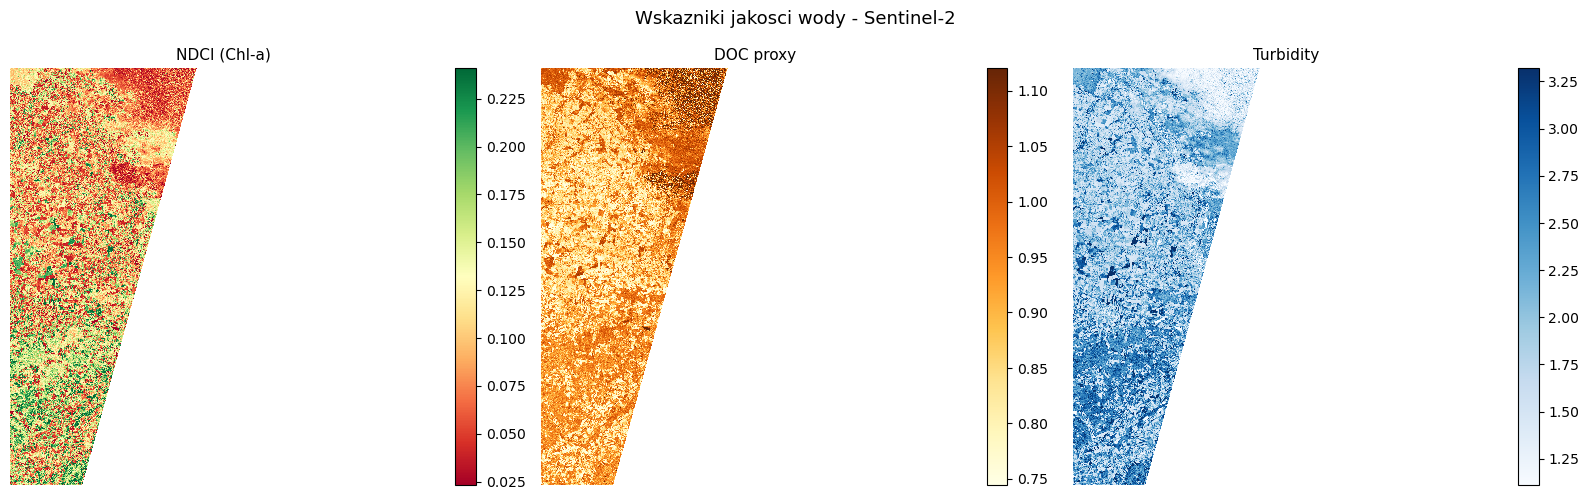

In [11]:
NDCI_s2 = safe_ratio(s2["B05"] - s2["B04"], s2["B05"] + s2["B04"])
DOC_s2  = safe_ratio(s2["B02"], s2["B04"])
TURB_s2 = safe_ratio(s2["B8A"], s2["B03"])

indices_s2 = {"NDCI (Chl-a)": NDCI_s2, "DOC proxy": DOC_s2, "Turbidity": TURB_s2}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, data) in zip(axes, indices_s2.items()):
    valid = data[~np.isnan(data)]
    vmin, vmax = np.percentile(valid, [2, 98])
    im = ax.imshow(data, cmap=CMAPS[name], vmin=vmin, vmax=vmax,
                   interpolation="nearest", aspect="auto")
    ax.set_title(name, fontsize=11)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("Wskazniki jakosci wody - Sentinel-2", fontsize=13)
fig.tight_layout()
plt.savefig("water_quality_s2.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Porownanie wynikow: lotnicze vs Sentinel-2

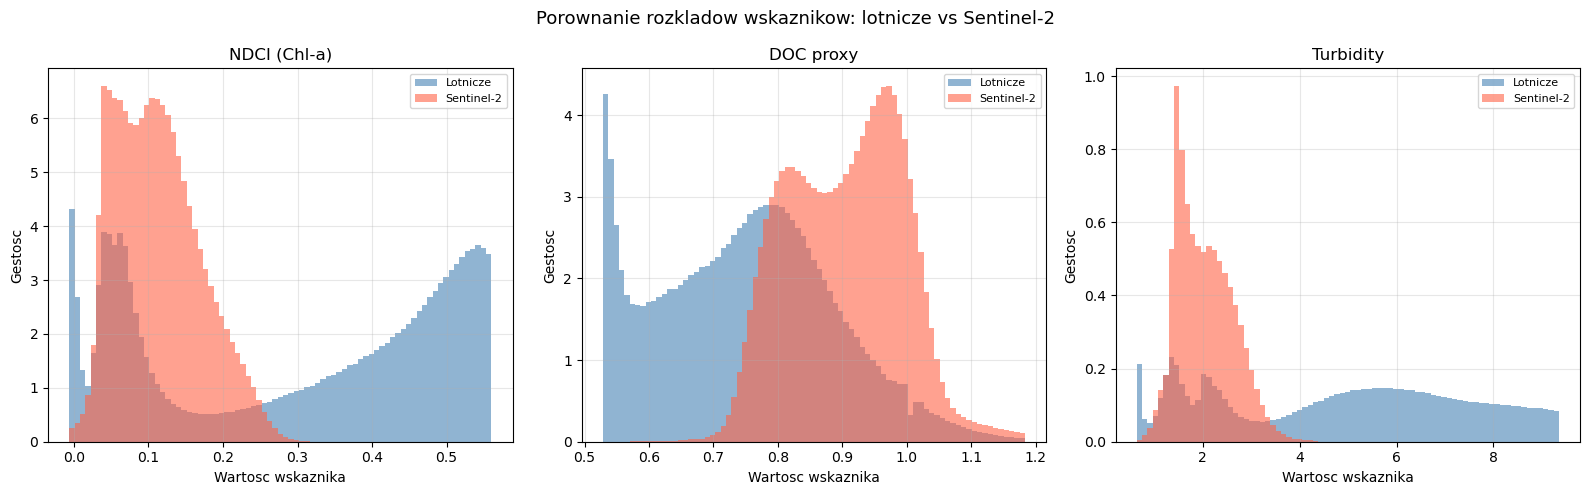

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, name in zip(axes, ["NDCI (Chl-a)", "DOC proxy", "Turbidity"]):
    a = indices_air[name][~np.isnan(indices_air[name])].ravel()
    s = indices_s2[name][~np.isnan(indices_s2[name])].ravel()
    lo, hi = np.percentile(np.concatenate([a, s]), [1, 99])
    bins = np.linspace(lo, hi, 80)
    ax.hist(a, bins=bins, alpha=0.6, color="steelblue", label="Lotnicze",   density=True)
    ax.hist(s, bins=bins, alpha=0.6, color="tomato",    label="Sentinel-2", density=True)
    ax.set_title(name)
    ax.set_xlabel("Wartosc wskaznika")
    ax.set_ylabel("Gestosc")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("Porownanie rozkladow wskaznikow: lotnicze vs Sentinel-2", fontsize=13)
fig.tight_layout()
plt.savefig("comparison_histograms.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
print(f"{'Wskaznik':<20} {'Zrodlo':<12} {'Mean':>8} {'Std':>8} {'P25':>8} {'P75':>8}")
print("-" * 66)
for name in ["NDCI (Chl-a)", "DOC proxy", "Turbidity"]:
    for label, idx_dict in [("Lotnicze", indices_air), ("Sentinel-2", indices_s2)]:
        v = idx_dict[name][~np.isnan(idx_dict[name])].ravel()
        print(f"{name:<20} {label:<12} "
              f"{np.mean(v):>8.4f} {np.std(v):>8.4f} "
              f"{np.percentile(v,25):>8.4f} {np.percentile(v,75):>8.4f}")
    print()

Wskaznik             Zrodlo           Mean      Std      P25      P75
------------------------------------------------------------------
NDCI (Chl-a)         Lotnicze       0.3148   0.2208   0.0694   0.5165
NDCI (Chl-a)         Sentinel-2     0.1125   0.0578   0.0660   0.1507

DOC proxy            Lotnicze       0.7222   0.1562   0.5858   0.8313
DOC proxy            Sentinel-2     0.9087   0.0986   0.8317   0.9755

Turbidity            Lotnicze       5.0948   3.4021   1.8691   7.6319
Turbidity            Sentinel-2     2.0445   0.5781   1.5616   2.4546

